In [1]:
import PyCrystalField as cef

 *******************************************************
 *                PyCrystalField 2.3.11               *
 *  Please cite  J. Appl. Cryst. (2021). 54, 356-362   * 
 *    <https://doi.org/10.1107/S160057672001554X>      *
 *******************************************************



In [2]:
CeIn3Lig, Ce = cef.importCIF(
    "CeIn3.cif",
    mag_ion="Ce0"   # not Ce0 if your manual CIF labels it Ce1
    # CoordinationNumber=12,
    # Zaxis=[0, 0, 1],
    # Yaxis=[0, 1, 0],
    
)

unit cell: 4.70762 4.70762 4.70762 90.0 90.0 90.0
Importing atoms
   4 atoms added
.cif import complete.
Central ion: Ce at [0.0, 0.0, 0.0]
    AAAH! There is a super-close atom. Removing it...
 Nearest ligand: In
   Identified 12 In ligands.
    No mirror planes and no rotations in point group: ['x, y, z']
	Found a near-4-fold axis...  CSM= 1.0567988542424145e-22
    No charges found in cif file... guessing the In ligands are charged -2 ,
       and assuming the central ion has a 3+ charge: Ce3+

  Axes for point charge model (in ABC space):
        X axis = [ 1.99148016e-13 -1.00000000e+00  7.45964590e-13] 
        Y axis = [ 1.00000000e+00  1.99148016e-13 -1.99148016e-13] 
        Z axis = [1.99148016e-13 7.45964590e-13 1.00000000e+00] 

        we must inlcude the -m terms, and the eigenkets will be complex.

   Creating a point charge model...
B_2 -2  =  0.0
B_2 -1  =  0.0
B_2 0  =  -0.0
B_2 1  =  0.0
B_2 2  =  -0.0
B_4 -4  =  0.0
B_4 -3  =  0.0
B_4 -2  =  0.0
B_4 -1  =  0.0
B_4 0

Pseudo-critical field from max d<Sz>/dEb:
Eb* = 9.462973
Peak d<Sz>/dEb = 182.345658

Weighted crossover estimate:
Eb* = 9.461723 ± 0.001250

FWHM crossover estimate:
Eb* = 9.461723 ± 0.001250
FWHM range: [9.460473, 9.462973]


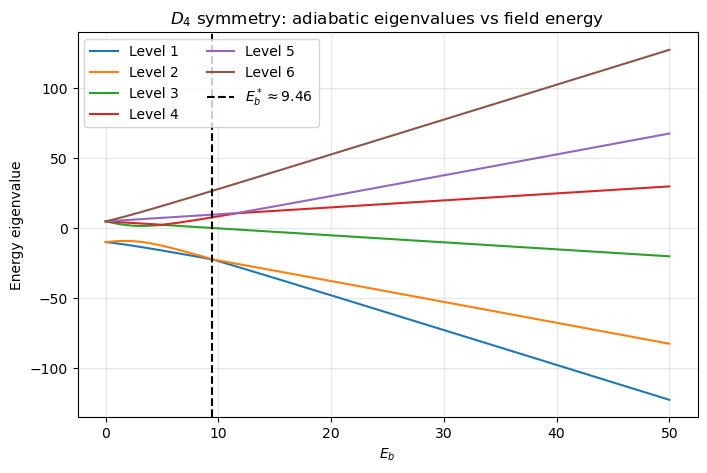

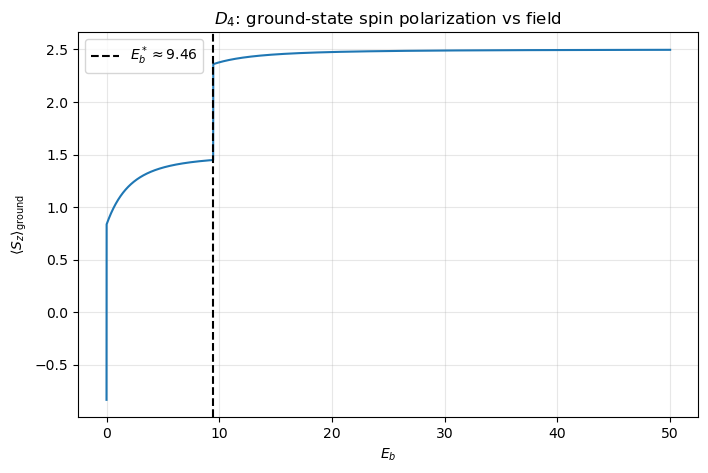

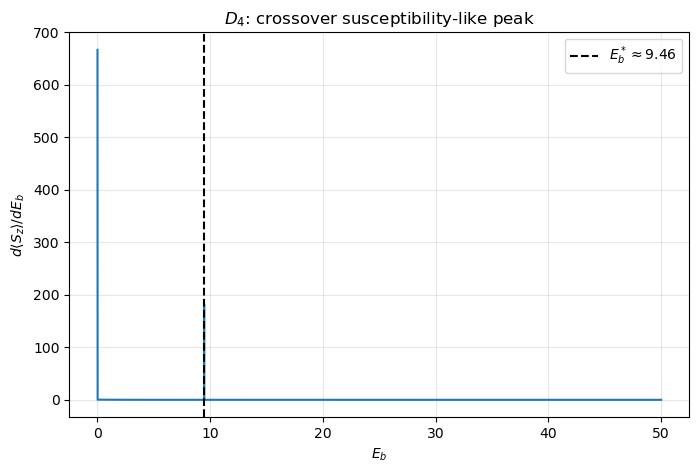

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# D4 symmetry: field analysis
# =========================

sqrt = np.sqrt

# =========================
# Stevens / crystal-field parameters
# Replace these with your D4 values
# =========================

B20 = 0.0
B40 = -0.04117266
B44 = -0.205863299668129

S = 5/2

# Basis ordering:
# |5/2>, |1/2>, |-3/2>, |-5/2>, |-1/2>, |3/2>
m_vals = np.array([5/2, 1/2, -3/2, -5/2, -1/2, 3/2], dtype=float)
Sz = np.diag(m_vals)

# =========================
# D4 Hamiltonian
# =========================

d4 = np.array([
    [10*B20 - 60*B40,        0,                 12*sqrt(5)*B44],
    [0,                    -8*B20 - 120*B40,    0],
    [12*sqrt(5)*B44,         0,                -2*B20 + 180*B40]
], dtype=float)

H_D4 = np.block([
    [d4, np.zeros((3, 3))],
    [np.zeros((3, 3)), d4]
])

def H_D4_with_field(Eb):
    """
    Matrix-first treatment:
    include -Eb * Sz in the Hamiltonian before diagonalizing.
    """
    return H_D4 - Eb * Sz

def eig_D4(Eb):
    return np.linalg.eigvalsh(H_D4_with_field(Eb))

def eigh_D4(Eb):
    return np.linalg.eigh(H_D4_with_field(Eb))


# =========================
# Field grid
# =========================

Eb_grid = np.linspace(0, 50, 20000)

evals = []
ground_magnetization = []

for Eb in Eb_grid:
    w, v = eigh_D4(Eb)

    evals.append(w)

    psi0 = v[:, 0]
    mz0 = np.real(np.conj(psi0) @ Sz @ psi0)
    ground_magnetization.append(mz0)

evals = np.array(evals)
ground_magnetization = np.array(ground_magnetization)


# =========================
# Method 1:
# pseudo-critical field from maximum slope of <Sz>
# =========================

dM_dEb = np.gradient(ground_magnetization, Eb_grid)

# Ignore Eb = 0 because Kramers degeneracy can create artificial behavior there
mask = Eb_grid > 1.0

idx_peak = np.argmax(dM_dEb[mask])
idx_peak_global = np.where(mask)[0][idx_peak]

Eb_peak = Eb_grid[idx_peak_global]
chi_peak = dM_dEb[idx_peak_global]

print("Pseudo-critical field from max d<Sz>/dEb:")
print(f"Eb* = {Eb_peak:.6f}")
print(f"Peak d<Sz>/dEb = {chi_peak:.6f}")


# =========================
# Estimate crossover width
# Treat d<Sz>/dEb as a weighted distribution
# =========================

chi = np.clip(dM_dEb, 0, None)

threshold = 0.10 * np.max(chi[mask])
peak_region = mask & (chi > threshold)

Eb_mean = np.sum(Eb_grid[peak_region] * chi[peak_region]) / np.sum(chi[peak_region])
Eb_std = np.sqrt(
    np.sum((Eb_grid[peak_region] - Eb_mean)**2 * chi[peak_region])
    / np.sum(chi[peak_region])
)

print()
print("Weighted crossover estimate:")
print(f"Eb* = {Eb_mean:.6f} ± {Eb_std:.6f}")


# =========================
# FWHM estimate
# =========================

half_max = 0.5 * np.max(chi[mask])
fwhm_region = mask & (chi >= half_max)

Eb_fwhm_low = Eb_grid[fwhm_region][0]
Eb_fwhm_high = Eb_grid[fwhm_region][-1]
Eb_fwhm_center = 0.5 * (Eb_fwhm_low + Eb_fwhm_high)
Eb_fwhm_half_width = 0.5 * (Eb_fwhm_high - Eb_fwhm_low)

print()
print("FWHM crossover estimate:")
print(f"Eb* = {Eb_fwhm_center:.6f} ± {Eb_fwhm_half_width:.6f}")
print(f"FWHM range: [{Eb_fwhm_low:.6f}, {Eb_fwhm_high:.6f}]")


# =========================
# Plot 1: eigenvalues
# =========================

plt.figure(figsize=(8, 5))

for i in range(6):
    plt.plot(Eb_grid, evals[:, i], label=f"Level {i+1}")

plt.axvline(Eb_mean, color="k", linestyle="--", label=rf"$E_b^* \approx {Eb_mean:.2f}$")
plt.axvspan(Eb_mean - Eb_std, Eb_mean + Eb_std, alpha=0.2)

plt.xlabel(r"$E_b$")
plt.ylabel("Energy eigenvalue")
plt.title(r"$D_4$ symmetry: adiabatic eigenvalues vs field energy")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()


# =========================
# Plot 2: ground-state <Sz>
# =========================

plt.figure(figsize=(8, 5))

plt.plot(Eb_grid, ground_magnetization)
plt.axvline(Eb_mean, color="k", linestyle="--", label=rf"$E_b^* \approx {Eb_mean:.2f}$")
plt.axvspan(Eb_mean - Eb_std, Eb_mean + Eb_std, alpha=0.2)

plt.xlabel(r"$E_b$")
plt.ylabel(r"$\langle S_z \rangle_{\mathrm{ground}}$")
plt.title(r"$D_4$: ground-state spin polarization vs field")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# =========================
# Plot 3: derivative peak
# =========================

plt.figure(figsize=(8, 5))

plt.plot(Eb_grid, dM_dEb)
plt.axvline(Eb_mean, color="k", linestyle="--", label=rf"$E_b^* \approx {Eb_mean:.2f}$")
plt.axvspan(Eb_mean - Eb_std, Eb_mean + Eb_std, alpha=0.2)

plt.xlabel(r"$E_b$")
plt.ylabel(r"$d\langle S_z \rangle / dE_b$")
plt.title(r"$D_4$: crossover susceptibility-like peak")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [6]:
import numpy as np
import plotly.graph_objects as go

# =========================
# D4 heat capacity / Maple form contour plot
# C = d² ln(Z) / dβ² = <E²> - <E>²
# β = 1/T
# =========================

T_grid = np.linspace(0.1, 10, 250)
Eb_grid_heat = np.linspace(0, 50, 250)

C_grid_maple = np.zeros((len(T_grid), len(Eb_grid_heat)))


for j, Eb in enumerate(Eb_grid_heat):
    E = eig_D4(Eb)

    # Stability shift; does not change variance
    E = E - np.min(E)

    for i, T in enumerate(T_grid):
        beta = 1 / T

        weights = np.exp(-beta * E)
        Z = np.sum(weights)

        E_avg = np.sum(E * weights) / Z
        E2_avg = np.sum(E**2 * weights) / Z

        # Maple form: d² ln(Z)/dβ² = <E²> - <E>²
        C_grid_maple[i, j] = E2_avg - E_avg**2


# =========================
# Optional analytic D4 crossing estimates
# =========================

Eb_cross_1 = 3*B20 - 60*B40
Eb_cross_2 = -3*B20 + 60*B40
Delta_min = 24*np.sqrt(5)*abs(B44)

print("D4 analytic estimates:")
print(f"Eb^(0,1) = {Eb_cross_1:.6f}")
print(f"Eb^(0,2) = {Eb_cross_2:.6f}")
print(f"Delta_min = {Delta_min:.6f}")

Eb_lower = Eb_mean - Eb_std
Eb_center = Eb_mean
Eb_upper = Eb_mean + Eb_std

print("Estimated transition range:")
print(f"Lower  = {Eb_lower:.6f}")
print(f"Mean   = {Eb_center:.6f}")
print(f"Upper  = {Eb_upper:.6f}")


# =========================
# Above-view contour plot
# =========================

fig = go.Figure(data=[
    go.Contour(
        x=Eb_grid_heat,
        y=T_grid,
        z=C_grid_maple,
        colorscale="Viridis",
        colorbar=dict(title=r"$\langle E^2\rangle-\langle E\rangle^2$"),
        contours=dict(
            coloring="heatmap",
            showlines=True
        )
    )
])

# Only plot positive crossing fields inside the scan range
if 0 <= Eb_cross_1 <= Eb_grid_heat.max():
    fig.add_vline(
        x=Eb_cross_1,
        line_dash="dash",
        line_color="white",
        annotation_text=r"$E_{b,D_4}^{(0,1)}$",
        annotation_position="top"
    )

if 0 <= Eb_cross_2 <= Eb_grid_heat.max():
    fig.add_vline(
        x=Eb_cross_2,
        line_dash="dot",
        line_color="white",
        annotation_text=r"$E_{b,D_4}^{(0,2)}$",
        annotation_position="top"
    )

fig.update_layout(
    title=(
        r"D4: Heat-Capacity Contour, Maple Form "
        f"(B20={B20}, B40={B40}, B44={B44})"
    ),
    xaxis_title=r"Field Energy $E_b$",
    yaxis_title=r"Temperature $T$",
    width=850,
    height=650
)

# Mean transition estimate
fig.add_vline(
    x=Eb_center,
    line_dash="dash",
    line_color="white",
    annotation_text=r"$\overline{E_b}$",
    annotation_position="top"
)

# Lower bound
fig.add_vline(
    x=Eb_lower,
    line_dash="dot",
    line_color="white",
    annotation_text=r"$\overline{E_b}-\sigma$",
    annotation_position="bottom"
)

# Upper bound
fig.add_vline(
    x=Eb_upper,
    line_dash="dot",
    line_color="white",
    annotation_text=r"$\overline{E_b}+\sigma$",
    annotation_position="bottom"
)

fig.show()

D4 analytic estimates:
Eb^(0,1) = 2.470360
Eb^(0,2) = -2.470360
Delta_min = 11.047784
Estimated transition range:
Lower  = 9.460473
Mean   = 9.461723
Upper  = 9.462973
